# № 1
## (5 балла)
Возьмите реализацию класса HashTable из лекционных материалов и выполните следующие доработки:
1. Реализуйте квадратичное пробирование как технику повторного хеширования.
2. Реализуйте работу с функцией len (переопределите метод __len__).
3. Реализуйте работу оператора in (переопределите метод __contains__).
4. Переделайте метод put таким образом, чтобы таблица автоматически меняла размер, когда загрузочный фактор становится больше значения 0.7. Размер должен увеличиваться примерно в два раза до ближайшего подходящего простого числа.
5. Реализуйте работу оператора del (переопределите метод __delitem__) для удаления элемента таблицы. Таблица должна автоматически менять размер, когда загрузочный фактор становится меньше значения 0.2. Размер должен уменьшаться примерно в два раза до ближайшего подходящего простого числа.

Все выполненные доработки должны быть протестированы.


In [10]:
# для 4го и 5го нужны простые числа:
def is_prime(n):
    if n <= 1:
        return False
    if n <= 3:
        return True
    if n % 2 == 0 or n % 3 == 0:
        return False
    i = 5
    while i * i <= n:
        if n % i == 0 or n % (i + 2) == 0:
            return False
        i += 6 # обусловлено тем что простые числа = 6k +- 1
    return True
    
def next_prime(n):
    while True:
        if is_prime(n):
            return n
        n += 1

class HashTable:
    def __init__(self):
        self.size = 11
        self.slots = [None] * self.size
        self.data = [None] * self.size
        self.count = 0
        self.DELETED = object()
    
    # 4) put upd
    def put(self, key, value):
        # проверка на фактор загрузки по условию 4
        if (self.count + 1) / self.size > 0.7:
            self._resize(next_prime(self.size * 2))
            
        hashvalue = self.hashfunction(key)
        i = 0
        
        while True:
            pos = self.quadratic_probing(hashvalue, i)
            if self.slots[pos] is None or self.slots[pos] is self.DELETED:
                self.slots[pos] = key
                self.data[pos] = value 
                self.count += 1
                return
            elif self.slots[pos] == key:
                self.data[pos] = value # замена
                return
            i += 1

    def hashfunction(self, key): # убрала size из аргументов тк это было странно
        return key % self.size
    
    def rehash(self, oldhash, size):
        return (oldhash + 1) % size

    def get(self, key):
        hashvalue = self.hashfunction(key)
        i = 0 # добалвено
        
        while i < self.size:
            pos = self.quadratic_probing(hashvalue, i)
            if self.slots[pos] is None:
                return None
            elif self.slots[pos] == key:
                return self.data[pos]
            i += 1
        return None

    def __getitem__(self, key):
        return self.get(key)

    def __setitem__(self, key, data):
        self.put(key, data)
        
    ## добавляем ф-ции
    # 1) квадратичное пробирование
    def quadratic_probing(self, hashvalue, i):
        return (hashvalue + i*i) % self.size

    # 2) len
    def __len__(self):
        return self.count
    
    # 3) in 
    def __contains__(self, key):
        return self.get(key) is not None
    
    def _resize(self, new_size):
        old_slots = self.slots
        old_data = self.data 
        self.size = new_size
        self.slots = [None] * self.size
        self.data = [None] * self.size
        
        self.count = 0
        for key, value in zip(old_slots, old_data):
            if key is not None and key is not self.DELETED:
                self.put(key, value)
           
    # 5) __delitem__     
    def __delitem__(self, key):
        hashvalue = self.hashfunction(key)
        i = 0
        while i < self.size:
            pos = self.quadratic_probing(hashvalue, i)
            if self.slots[pos] is None:
                raise KeyError(key)
            elif self.slots[pos] == key:
                self.slots[pos] = self.DELETED
                self.data[pos] = None
                self.count -= 1
                if self.size > 11 and self.count / self.size < 0.2:
                    new_size = max(11, next_prime(max(3, self.size // 2)))
                    self._resize(new_size)
                return
            i += 1
        raise KeyError(key)

    
hash_table1 = HashTable()
for key in range(15):  # Проверка автоувеличения размера + вставка
    hash_table1[key] = key * 10

print(len(hash_table1))       # Проверка __len__
print(5 in hash_table1)       # Проверка __contains__
print(hash_table1[5])         # Проверка get
del hash_table1[5]            # Проверка __delitem__ и автосжатия таблицы
# in работает по ключу, не по значению
print(5 in hash_table1)

for key in range(15):
    try:
        del hash_table1[key]
    except KeyError:
        pass
print(len(hash_table1))

15
True
50
False
0


# № 2
## (5 балла)
Возьмите реализацию класса HashTable из лекционных материалов и выполните следующие доработки:
1. Переделайте существующие методы так, чтобы разрешение коллизий происходило не при помощи концепции открытой адресации, а методом цепочек. Для этого в каждом слоте храните связный список, реализованный классом UnorderedList из лабораторной работы 3.
2. Реализуйте работу с функцией len (переопределите метод __len__).
3. Реализуйте работу оператора in (переопределите метод __contains__).
4. Переделайте метод put таким образом, чтобы таблица автоматически меняла размер, когда загрузочный фактор становится больше значения 0.7. Размер должен увеличиваться примерно в два раза до ближайшего подходящего простого числа.
5. Реализуйте работу оператора del (переопределите метод __delitem__) для удаления элемента таблицы. Таблица должна автоматически менять размер, когда загрузочный фактор становится меньше значения 0.2. Размер должен уменьшаться примерно в два раза до ближайшего подходящего простого числа.

Все выполненные доработки должны быть протестированы.


In [11]:
# реализация UnorderedList из лекции 3:
class Node:
    def __init__(self, initdata):
        self.data = initdata
        self.next = None

    def getData(self):
        return self.data

    def getNext(self):
        return self.next

    def setData(self, newdata):
        self.data = newdata

    def setNext(self, newnext):
        self.next = newnext


class UnorderedList:
    def __init__(self):
        self.head = None

    def isEmpty(self):
        return self.head == None

    def add(self, item):
        temp = Node(item)
        temp.setNext(self.head)
        self.head = temp

    def size(self):
        current = self.head
        count = 0
        while current != None:
            count = count + 1
            current = current.getNext()

        return count

    def search(self, item):
        current = self.head
        found = False
        while current != None and not found:
            if current.getData() == item:
                found = True
            else:
                current = current.getNext()

        return found

    def remove(self, item):
        current = self.head
        previous = None
        found = False
        while not found:
            if current.getData() == item:
                found = True
            else:
                previous = current
                current = current.getNext()

        if previous == None:
            self.head = current.getNext()
        else:
            previous.setNext(current.getNext())
            
# Переделываем хештейбл:
class HashTable2:
    def __init__(self):
        self.size = 11
        self.table = [UnorderedList() for _ in range(self.size)]
        self.count = 0

    def hashfunction(self, key):
        return key % self.size

    def put(self, key, data):
        index = self.hashfunction(key)
        bucket = self.table[index]
        if bucket.search((key, data)) is False:
            bucket.add((key, data))
            self.count += 1
            if self.load_factor() > 0.7:
                self.resize_up()

    def get(self, key):
        index = self.hashfunction(key)
        bucket = self.table[index]
        current = bucket.head
        while current is not None:
            if current.getData()[0] == key:
                return current.getData()[1]
            current = current.getNext()
        return None

    def __len__(self):
        return self.count

    def __contains__(self, key):
        index = self.hashfunction(key)
        bucket = self.table[index]
        current = bucket.head
        while current is not None:
            if current.getData()[0] == key:
                return True
            current = current.getNext()
        return False

    def __delitem__(self, key):
        index = self.hashfunction(key)
        bucket = self.table[index]
        current = bucket.head
        previous = None
        while current is not None:
            if current.getData()[0] == key:
                if previous is None:
                    bucket.head = current.getNext()
                else:
                    previous.setNext(current.getNext())
                self.count -= 1
                if self.load_factor() < 0.2:
                    self.resize_down()
                return
            previous = current
            current = current.getNext()
        raise KeyError(key)

    def load_factor(self):
        return self.count / self.size

    def resize_up(self):
        old_table = self.table
        old_size = self.size
        self.size = self.next_prime(self.size * 2)
        self.table = [UnorderedList() for _ in range(self.size)]
        self.count = 0
        for i in range(old_size):
            bucket = old_table[i]
            current = bucket.head
            while current is not None:
                key, data = current.getData()
                # Используем исправленный put для перехеширования
                self.put(key, data)
                current = current.getNext()
                
    def resize_down(self):
        old_table = self.table
        old_size = self.size
        new_size = self.next_prime(self.size // 2)
        if new_size < 11:
            new_size = 11
        self.size = new_size
        self.table = [UnorderedList() for _ in range(self.size)]
        self.count = 0
        for i in range(old_size):
            bucket = old_table[i]
            current = bucket.head
            while current is not None:
                key, data = current.getData()
                # Используем исправленный put для перехеширования
                self.put(key, data)
                current = current.getNext()

    def next_prime(self, n):
        def is_prime(num):
            if num < 2:
                return False
            for i in range(2, int(num ** 0.5) + 1):
                if num % i == 0:
                    return False
            return True
        while not is_prime(n):
            n += 1
        return n

    def __getitem__(self, key):
        return self.get(key)

    def __setitem__(self, key, data):
        self.put(key, data)

hash_table2 = HashTable2()
for key in range(15):  # Проверка автоувеличения размера + вставка
    hash_table2[key] = key * 10

print(len(hash_table2))       # Проверка __len__
print(5 in hash_table2)       # Проверка __contains__
print(hash_table2[5])         # Проверка get
del hash_table2[5]            # Проверка __delitem__ и автосжатия таблицы
# in работает по ключу, не по значению
print(5 in hash_table2)

for key in range(15):
    try:
        del hash_table2[key]
    except KeyError:
        pass
print(len(hash_table2))


15
True
50
False
0


# № 3
## (2 балла)
Переделайте класс HashTable, чтобы в качестве ключей можно было использовать строки.

In [12]:
# Переделываем хештейбл (опять):
# ВСЁ ТАКЖЕ, МЕНЯЕМ ТОЛЬКО hashfunction
# + добавим возможность вывода (__str__ для принта)
class HashTable3:
    def __init__(self):
        self.size = 11
        self.table = [UnorderedList() for _ in range(self.size)]
        self.count = 0

    def hashfunction(self, key):
        if isinstance(key, int):
            return key % self.size
        elif isinstance(key, str):
            hash_value = 0
            for char in key:
                hash_value = (hash_value * 31 + ord(char)) % self.size
            return hash_value
        else:
            raise TypeError("Неподерживаемый тип ключа (не число, не строка)")
                
    def put(self, key, data):
        index = self.hashfunction(key)
        bucket = self.table[index]
        # Сначала ищем существующий ключ и обновляем его значение
        current = bucket.head
        while current is not None:
            if current.getData()[0] == key:
                # Нашли существующий ключ - обновляем значение
                # Создаем новую пару (key, data) для замены
                current.setData((key, data))
                return
            current = current.getNext()
        
        # Если ключ не найден - добавляем новый
        bucket.add((key, data))
        self.count += 1
        if self.load_factor() > 0.7:
            self.resize_up()

    def get(self, key):
        index = self.hashfunction(key)
        bucket = self.table[index]
        current = bucket.head
        while current is not None:
            if current.getData()[0] == key:
                return current.getData()[1]
            current = current.getNext()
        return None

    def __len__(self):
        return self.count

    def __contains__(self, key):
        index = self.hashfunction(key)
        bucket = self.table[index]
        current = bucket.head
        while current is not None:
            if current.getData()[0] == key:
                return True
            current = current.getNext()
        return False

    def __delitem__(self, key):
        index = self.hashfunction(key)
        bucket = self.table[index]
        current = bucket.head
        previous = None
        while current is not None:
            if current.getData()[0] == key:
                if previous is None:
                    bucket.head = current.getNext()
                else:
                    previous.setNext(current.getNext())
                self.count -= 1
                if self.load_factor() < 0.2:
                    self.resize_down()
                return
            previous = current
            current = current.getNext()
        raise KeyError(key)

    def load_factor(self):
        return self.count / self.size
     
    def resize_up(self):
        old_table = self.table
        old_size = self.size
        self.size = self.next_prime(self.size * 2)
        self.table = [UnorderedList() for _ in range(self.size)]
        self.count = 0
        for i in range(old_size):
            bucket = old_table[i]
            current = bucket.head
            while current is not None:
                key, data = current.getData()
                # Используем исправленный put для перехеширования
                self.put(key, data)
                current = current.getNext()
                
    def resize_down(self):
        old_table = self.table
        old_size = self.size
        new_size = self.next_prime(self.size // 2)
        if new_size < 11:
            new_size = 11
        self.size = new_size
        self.table = [UnorderedList() for _ in range(self.size)]
        self.count = 0
        for i in range(old_size):
            bucket = old_table[i]
            current = bucket.head
            while current is not None:
                key, data = current.getData()
                # Используем исправленный put для перехеширования
                self.put(key, data)
                current = current.getNext()

    def next_prime(self, n):
        def is_prime(num):
            if num < 2:
                return False
            for i in range(2, int(num ** 0.5) + 1):
                if num % i == 0:
                    return False
            return True
        while not is_prime(n):
            n += 1
        return n

    def __getitem__(self, key):
        return self.get(key)

    def __setitem__(self, key, data):
        self.put(key, data)
        
    # принт для удобства
    def __str__(self):
        items = []
        for chain in self.table:
            current = chain.head
            while current:
                key, value = current.getData()
                items.append(f"{key}: {value}")
                current = current.getNext()
        return f"Размер = {self.size}\nЭлементов = {self.count}\nСодержимое: {{{', '.join(items)}}}"

        

hash_table3 = HashTable3()
hash_table3['word'] = 123
hash_table3['str_str'] = 456
hash_table3[2] = 'age'

print(hash_table3)


Размер = 11
Элементов = 3
Содержимое: {2: age, word: 123, str_str: 456}


# № 4
## (2 балла)
Дана строчка русского текста, состоящая из слов и пробелов. Словом считается последовательность русских букв, слова разделены одним или большим числом пробелов.

Для каждого слова этого текста узнайте порядковый номер его вхождения в текст именно в той форме, в которой указано слово. Для первого вхождения слова выведите «1», для второго вхождения того же слова выведите «2» и так далее. 

Для решения этой задачи используйте класс HashTable из задания № 3.

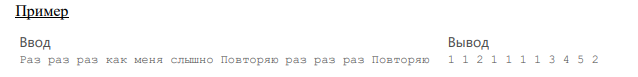

In [15]:
def task4():
    input_text_test = "Раз раз раз как меня слышно Повторяю раз раз раз Повторяю"
    user_input = input("Введите 1 для тестового запуска, 2 для вашего текста")
    choice = int(user_input)
    if choice == 1:
        text = input_text_test
    else:
        text = input("Введите ваш текст: ")
    words = text.strip().split()
    hashtable = HashTable3()
    result = []
    for word in words:
        current = hashtable.get(word)
        if current is None:
            hashtable[word] = 1
            result.append(1)
        else:
            hashtable[word] = current + 1
            result.append(current + 1)
    return result

occurrences = task4()
print(occurrences)

[1, 1, 2, 1, 1, 1, 1, 3, 4, 5, 2]


# № 5
## (3 балла)
Напишите программу, имитирующую процесс регистрации и авторизации. Для каждого пользователя программа должна сохранять логин, хеш его пароля и «соль». Для хранения данных можно использовать БД или файл.

Действия при сохранении пароля:
1. Сгенерируйте длинную случайную «соль» при помощи модуля secrets [secrets - Generate secure random numbers for managing secrets — Python 3.10.0 documentation](https://docs.python.org/3/library/secrets.html). Длина «соли» должна быть такой же как и выходные данные используемой вами хэш-функции. Например, если для хеширования вы используете SHA256, то на выходе вы получите 256 бит (32 байта). В этом случае соль должна составлять не менее 32 случайных байт.
2. Добавьте «соль» к паролю и хэшируйте его с помощью функции scrypt из модуля hashlib [(Хеширование паролей модулем hashlib в Python. (docs-python.ru))](https://docs-python.ru/standart-library/modul-hashlib-python/heshirovanie-parolej-modulem-hashlib/).
3. Сохраните логин, «соль» и получившейся хэш в БД или в файл.

Действия при проверке пароля:

1. Извлеките «соль» и хэш пользователя из БД или файла.
2. Добавьте «соль» к введенному паролю и хэшируйте его, используя ту же хэшфункцию, что и в алгоритме сохранения пароля.
3. Сравните получившейся хэш введенного пароля с хэшом из БД или файла. Если они совпадают, то пароль правильный. В противном случае пароль был введен неверно.

In [20]:
import hashlib
import secrets
import json
import os

class PasswordManager:
    def __init__(self, storage_file='users.json'):
        self.storage_file = storage_file
        self.users = self._load_users()
    
    def _load_users(self):
        if os.path.exists(self.storage_file):
            try:
                with open(self.storage_file, 'r', encoding='utf-8') as f:
                    return json.load(f)
            except (json.JSONDecodeError, FileNotFoundError):
                return {}
        return {}
    
    def _save_users(self):
        with open(self.storage_file, 'w', encoding='utf-8') as f:
            json.dump(self.users, f, ensure_ascii=False, indent=2)
    
    def _generate_salt(self):
        return secrets.token_bytes(32)
    
    def _hash_password(self, password, salt):
        password_bytes = password.encode('utf-8')
        
        hashed = hashlib.scrypt(
            password_bytes, 
            salt=salt, 
            n=16384, 
            r=8, 
            p=1, 
            dklen=32
        )
        return hashed
    
    def register_user(self, login, password):
        if login in self.users:
            print("Ошибка: Пользователь с таким логином уже существует!")
            return False
        
        salt = self._generate_salt()
        password_hash = self._hash_password(password, salt)
        
        self.users[login] = {
            'salt': salt.hex(),
            'password_hash': password_hash.hex()
        }
        
        self._save_users()
        print(f"Пользователь '{login}' успешно зарегистрирован!")
        return True
    
    def verify_password(self, login, password):
        if login not in self.users:
            print("Ошибка: Пользователь не найден!")
            return False
        
        user_data = self.users[login]
        
        salt = bytes.fromhex(user_data['salt'])
        stored_hash = bytes.fromhex(user_data['password_hash'])
        
        input_hash = self._hash_password(password, salt)
        
        if secrets.compare_digest(input_hash, stored_hash):
            print("Пароль верный! Авторизация успешна.")
            return True
        else:
            print("Ошибка: Неверный пароль!")
            return False
    
    def user_exists(self, login):
        return login in self.users
    
    def list_users(self):
        if not self.users:
            print("Нет зарегистрированных пользователей.")
        else:
            print("Зарегистрированные пользователи:")
            for login in self.users.keys():
                print(f"  - {login}")

def main():
    password_manager = PasswordManager()
    
    while True:
        print("\n=== Войдите или зарегистрируйтесь ===")
        print("1. Регистрация")
        print("2. Авторизация")
        print("3. Список пользователей")
        print("4. Выход")
        
        choice = input("Выберите действие (1-4): ").strip()
        
        if choice == '1':
            print("\n--- Регистрация ---")
            login = input("Введите логин: ").strip()
            password = input("Введите пароль: ").strip()
            
            if not login or not password:
                print("Ошибка: Логин и пароль не могут быть пустыми!")
                continue
                
            password_manager.register_user(login, password)
            
        elif choice == '2':
            print("\n--- Авторизация ---")
            login = input("Введите логин: ").strip()
            password = input("Введите пароль: ").strip()
            
            if not login or not password:
                print("Ошибка: Логин и пароль не могут быть пустыми!")
                continue
                
            password_manager.verify_password(login, password)
            
        elif choice == '3':
            print("\n--- Список пользователей ---")
            password_manager.list_users()
            
        elif choice == '4':
            print("Выход из программы...")
            break
            
        else:
            print("Ошибка: Неверный выбор! Попробуйте снова.")

if __name__ == "__main__":
    main()


=== Войдите или зарегистрируйтесь ===
1. Регистрация
2. Авторизация
3. Список пользователей
4. Выход

--- Список пользователей ---
Зарегистрированные пользователи:
  - GreyF

=== Войдите или зарегистрируйтесь ===
1. Регистрация
2. Авторизация
3. Список пользователей
4. Выход

--- Авторизация ---
Ошибка: Пользователь не найден!

=== Войдите или зарегистрируйтесь ===
1. Регистрация
2. Авторизация
3. Список пользователей
4. Выход

--- Авторизация ---
Пароль верный! Авторизация успешна.

=== Войдите или зарегистрируйтесь ===
1. Регистрация
2. Авторизация
3. Список пользователей
4. Выход
Выход из программы...


# № 6
## (3 балла)
Напишите программу, которая принимает от пользователя путь до директории. Для всех файлов из данной директории должен быть вычислен хеш. Программа должна выявить и вывести на экран все дубликаты в этой директории (т.е. файлы, у которых одинаковый хеш).

In [19]:
def task6():
    pass